# **Experiment Notebook**



In [1]:
# Do not modify this code
# !pip install -q utstd

from utstd.ipyrenders import *

In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [191]:
import os
import time
import requests
from datetime import datetime
from pathlib import Path
from utstd.ipyrenders import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

import pickle

---
## A. Project Description


In [5]:
# <Student to fill this section>
student_name = "Saurabh Sabharwal"
student_id = "25606169"
group_id = "Group 30"

In [6]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [7]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

In [8]:
# Do not modify this code
print_tile(size="h1", key='group_id', value=group_id)

---
## B. Business Understanding

In [176]:
# <Student to fill this section>
business_use_case_description = """
Launching a product leveraging CoinGecko API to display market indicators and make predictions for Bitcoin
"""

In [177]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [178]:
# <Student to fill this section>
business_objectives = """
To be able to succesfully predict the high price for next day as close to the real value as possible. Incorrect or inaccurate may result in loss in investment, loss in trust and confidence, and any possible legal action.
"""

In [179]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [180]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
The results may be used for research purposes, financial advice, as an API to future projects. Stakeholders include investors, app users, analysts, investment firms.
"""

In [181]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


> Making sure we are in the right directory
- For my project, I worked using the original directory which matches to the github repository
- Hence the variable orgPath stores the intial directory, i.e. project repo root
- Then we link it to the data/raw folder to fetch original files

In [ ]:
# originalSaurabh = r"C:\Users\lenovo\Desktop\Labs Sem 2\Adv ML\at3\36120-group30-experiments"
# os.chdir(originalSaurabh)

In [16]:
orgPath = os.getcwd()
path = os.path.join(orgPath, "data", "raw", "Bitcoin")

In [17]:
os.chdir(path)

In [18]:
def load_and_combine_csvs(path: str):
    """
    Load all CSV files from the given path, convert time columns, 
    and combine into a single DataFrame sorted by 'timeOpen'.
    
    Parameters:
        path (str): Path to the folder containing CSV files.

    Returns:
        pd.DataFrame: Combined and sorted dataframe.
    """
    dataframes = []

    for file in os.listdir(path):
        if file.endswith(".csv"):
            tempDF = pd.read_csv(os.path.join(path, file), sep=';')
            tempDF['timeOpen'] = pd.to_datetime(tempDF['timeOpen'])
            tempDF['timeClose'] = pd.to_datetime(tempDF['timeClose'])
            tempDF['timestamp'] = pd.to_datetime(tempDF['timestamp'])
            dataframes.append(tempDF)

    if not dataframes:
        raise ValueError(f"No CSV files found in directory: {path}")

    # Combine all DataFrames and sort by 'timeOpen'
    df_clean = pd.concat(dataframes, ignore_index=True)
    df_clean = df_clean.sort_values(by='timeOpen').reset_index(drop=True)

    return df_clean


In [19]:
df = load_and_combine_csvs(path)

In [20]:
os.chdir(orgPath)
os.getcwd()

'C:\\Users\\lenovo\\Desktop\\Labs Sem 2\\Adv ML\\at3\\36120-group30-experiments'

In [21]:
df.tail()

,timeOpen,timeClose,timeHigh,timeLow,name,open,high,low,close,volume,marketCap,timestamp
3648,2024-12-27 00:00:00+00:00,2024-12-27 23:59:59.999000+00:00,2024-12-27T09:07:00.000Z,2024-12-27T17:25:00.000Z,2781,95704.974586,97294.846420,93310.743804,94164.860348,5.241993e+10,1.864542e+12,2024-12-27 23:59:59.999000+00:00
3649,2024-12-28 00:00:00+00:00,2024-12-28 23:59:59.999000+00:00,2024-12-28T22:53:00.000Z,2024-12-28T01:27:00.000Z,2781,94160.186223,95525.898522,94014.286497,95163.931926,2.410744e+10,1.884684e+12,2024-12-28 23:59:59.999000+00:00
3650,2024-12-29 00:00:00+00:00,2024-12-29 23:59:59.999000+00:00,2024-12-29T00:00:00.000Z,2024-12-29T23:12:00.000Z,2781,95174.055117,95174.878402,92881.791870,93530.228438,2.963589e+10,1.852119e+12,2024-12-29 23:59:59.999000+00:00
3651,2024-12-30 00:00:00+00:00,2024-12-30 23:59:59.999000+00:00,2024-12-30T20:25:00.000Z,2024-12-30T15:11:00.000Z,2781,93527.197497,94903.323896,91317.135460,92643.214604,5.618800e+10,1.834643e+12,2024-12-30 23:59:59.999000+00:00
3652,2024-12-31 00:00:00+00:00,2024-12-31 23:59:59.999000+00:00,2024-12-31T14:35:00.000Z,2024-12-31T01:32:00.000Z,2781,92643.251222,96090.603788,91914.027783,93429.202811,4.362511e+10,1.850183e+12,2024-12-31 23:59:59.999000+00:00


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3653 entries, 0 to 3652
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype              
---  ------     --------------  -----              
 0   timeOpen   3653 non-null   datetime64[ns, UTC]
 1   timeClose  3653 non-null   datetime64[ns, UTC]
 2   timeHigh   3653 non-null   object             
 3   timeLow    3653 non-null   object             
 4   name       3653 non-null   int64              
 5   open       3653 non-null   float64            
 6   high       3653 non-null   float64            
 7   low        3653 non-null   float64            
 8   close      3653 non-null   float64            
 9   volume     3653 non-null   float64            
 10  marketCap  3653 non-null   float64            
 11  timestamp  3653 non-null   datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](3), float64(6), int64(1), object(2)
memory usage: 342.6+ KB


Exploring the API sources (CoinGecko)

In [23]:
coin_id = "bitcoin"
api_key = "CG-b1GPH8CCVXWw6u2NxvKDzccg"

In [24]:
url = "https://api.coingecko.com/api/v3/coins/list"
headers = {"x-cg-demo-api-key": api_key}

response = requests.get(url, headers=headers)

if response.status_code == 200:
    data = response.json()
    df_coin = pd.DataFrame(data)

    # df.to_csv("coin_list.csv", index=False)
else:
    print(f"Error {response.status_code}: {response.text}")

df_coin[df_coin['id'] =='bitcoin']

,id,symbol,name
2258,bitcoin,btc,Bitcoin


In [25]:
url = f"https://api.coingecko.com/api/v3/coins/{coin_id}/ohlc"
params = {"vs_currency": "usd", "days": "365"}
headers = {"x-cg-demo-api-key": "CG-b1GPH8CCVXWw6u2NxvKDzccg"}

response = requests.get(url, headers=headers, params=params)

if response.status_code == 200:
    data = response.json()

    df_api_ohlc = pd.DataFrame(data, columns=["timestamp", "open", "high", "low", "close"])

    df_api_ohlc["timestamp"] = pd.to_datetime(df_api_ohlc["timestamp"], unit="ms", utc=True)

    # df.to_csv(f"{coin_id}_ohlc.csv", index=False)
else:
    print(f"Error {response.status_code}: {response.text}")

df_api_ohlc.tail()


,timestamp,open,high,low,close
87,2025-10-15 00:00:00+00:00,113044.0,115934.0,109862.0,113157.0
88,2025-10-19 00:00:00+00:00,113066.0,113527.0,103856.0,107156.0
89,2025-10-23 00:00:00+00:00,107210.0,113804.0,106222.0,107618.0
90,2025-10-27 00:00:00+00:00,107591.0,114816.0,107581.0,114476.0
91,2025-10-31 00:00:00+00:00,114419.0,116041.0,106464.0,108241.0


In [26]:
vs_currency = "usd"
days = 90  

url = f"https://api.coingecko.com/api/v3/coins/{coin_id}/market_chart"
params = {"vs_currency": vs_currency, "days": days}
headers = {"x-cg-demo-api-key": api_key}

response = requests.get(url, headers=headers, params=params)
data = response.json()

df_api_market = pd.DataFrame({
    "time": [datetime.utcfromtimestamp(p[0] / 1000) for p in data["prices"]],
    "price": [p[1] for p in data["prices"]],
    "market_cap": [m[1] for m in data["market_caps"]],
    "total_volume": [v[1] for v in data["total_volumes"]]
})

df_api_market["time"] = pd.to_datetime(df_api_market["time"], utc=True)
df_api_market = df_api_market.sort_values("time").reset_index(drop=True)

df_api_market.tail()

,time,price,market_cap,total_volume
2157,2025-11-03 05:01:39.212000+00:00,107936.884907,2.152193e+12,4.435148e+10
2158,2025-11-03 06:01:17.472000+00:00,107571.490511,2.145391e+12,4.355191e+10
2159,2025-11-03 07:00:18.060000+00:00,107421.108890,2.145107e+12,4.502638e+10
2160,2025-11-03 08:01:07.947000+00:00,107533.415464,2.145759e+12,4.569234e+10
2161,2025-11-03 08:24:30+00:00,107411.639247,2.142164e+12,4.571712e+10


Combining OHLC API and market valuations API in one dataframe to have a training data alike dataset
> This will also be used in streamlit widgets **(maximum data available with free API: 90 days)**

In [27]:
days = 90

headers = {"x-cg-demo-api-key": api_key}

# Fetch OHLC data
url_ohlc = f"https://api.coingecko.com/api/v3/coins/{coin_id}/ohlc"
params_ohlc = {"vs_currency": vs_currency, "days": days}
ohlc_response = requests.get(url_ohlc, headers=headers, params=params_ohlc)
ohlc_data = ohlc_response.json()

df_ohlc = pd.DataFrame(ohlc_data, columns=["timestamp", "open", "high", "low", "close"])
df_ohlc["time"] = pd.to_datetime(df_ohlc["timestamp"], unit="ms", utc=True)
df_ohlc.drop(columns="timestamp", inplace=True)

# Fetch Market Chart data
url_market = f"https://api.coingecko.com/api/v3/coins/{coin_id}/market_chart"
params_market = {"vs_currency": vs_currency, "days": days}
market_response = requests.get(url_market, headers=headers, params=params_market)
market_data = market_response.json()

df_market = pd.DataFrame({
    "time": [datetime.utcfromtimestamp(p[0] / 1000) for p in market_data["prices"]],
    "price": [p[1] for p in market_data["prices"]],
    "market_cap": [m[1] for m in market_data["market_caps"]],
    "total_volume": [v[1] for v in market_data["total_volumes"]]
})
df_market["time"] = pd.to_datetime(df_market["time"], utc=True)

# Merge both on time
df_api_combined = pd.merge_asof(
    df_ohlc.sort_values("time"),
    df_market.sort_values("time"),
    on="time",
    direction="nearest",
    tolerance=pd.Timedelta("1h")
)

df_api_combined.tail()


,open,high,low,close,time,price,market_cap,total_volume
18,113044.0,115934.0,109862.0,113157.0,2025-10-15 00:00:00+00:00,113156.569438,2.257545e+12,9.121185e+10
19,113066.0,113527.0,103856.0,107156.0,2025-10-19 00:00:00+00:00,107156.003376,2.135576e+12,3.441284e+10
20,107210.0,113804.0,106222.0,107618.0,2025-10-23 00:00:00+00:00,107591.460509,2.146124e+12,8.384514e+10
21,107591.0,114816.0,107581.0,114476.0,2025-10-27 00:00:00+00:00,114476.012275,2.283691e+12,4.248327e+10
22,114419.0,116041.0,106464.0,108241.0,2025-10-31 00:00:00+00:00,108240.765287,2.157804e+12,7.264890e+10


### C.2 Define Target variable

In [28]:
df_clean = df.copy()

df_clean = df_clean[[
    'timestamp',
    'timeOpen',
    'timeHigh',
    'timeLow',
    'timeClose',
    'open',
    'high',
    'low',
    'close',
    'volume',
    'marketCap'
]]

In [29]:
df_clean['target_next_high'] = df_clean['high'].shift(-1)

# dropping the last row (since it won't have a next-day target)
df_clean = df_clean.dropna(subset=['target_next_high']).reset_index(drop=True)

In [30]:
# <Student to fill this section>
target_definition_explanations = """
Our predictions are based on the feature 'high'. We have defined our target variable, target_next_high, which essentially shows the value for the next entry, essentially next day's prediction. This will be used for training the dataset and make predictions on today's entry.
"""

In [31]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [32]:
target_name = 'target_next_high'

### C.4 Explore Target variable

In [33]:
time = 'timestamp'

In [34]:
df_clean[[time, target_name]].head()

,timestamp,target_next_high
0,2015-01-01 23:59:59.999000+00:00,315.838989
1,2015-01-02 23:59:59.999000+00:00,315.149994
2,2015-01-03 23:59:59.999000+00:00,287.230011
3,2015-01-04 23:59:59.999000+00:00,278.341003
4,2015-01-05 23:59:59.999000+00:00,287.553009


In [35]:
# pip install seaborn matplotlib

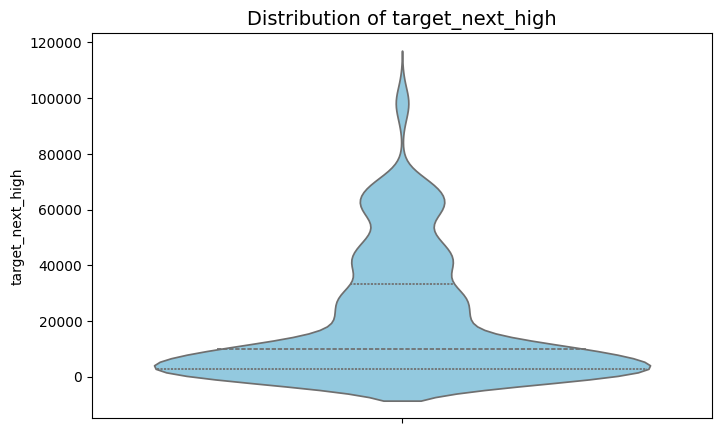

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.violinplot(data=df_clean, y=target_name, inner="quart", color="skyblue")
plt.title(f"Distribution of {target_name}", fontsize=14)
plt.ylabel(target_name)
plt.xlabel("")
plt.show()

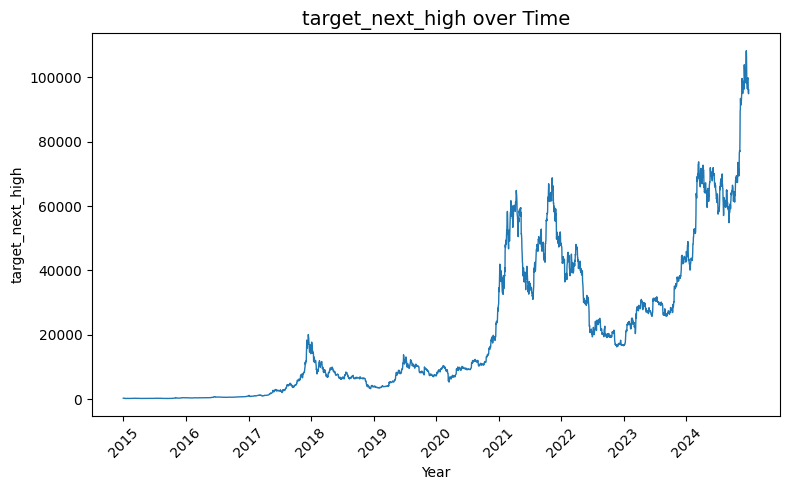

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(df_clean[time], df_clean[target_name], linewidth=1)
plt.title(f"{target_name} over Time", fontsize=14)
plt.xlabel("Year")
plt.ylabel(target_name)

# Format x-axis ticks to show only year labels
plt.xticks(
    ticks=pd.date_range(start=df_clean[time].min(), 
                        end=df_clean[time].max(), 
                        freq='YS'),
    labels=pd.date_range(start=df_clean[time].min(), 
                         end=df_clean[time].max(), 
                         freq='YS').year,
    rotation=45
)

plt.tight_layout()
plt.show()

In [38]:
# <Student to fill this section>
target_distribution_explanations = """
Target is highly right-skewed and has moved significantly in the last few years as compared to the origin of this dataset. This may cause problem while tackling model training, since this type of datapoints has never been seen in the past.
"""

In [39]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest `Price - Low`

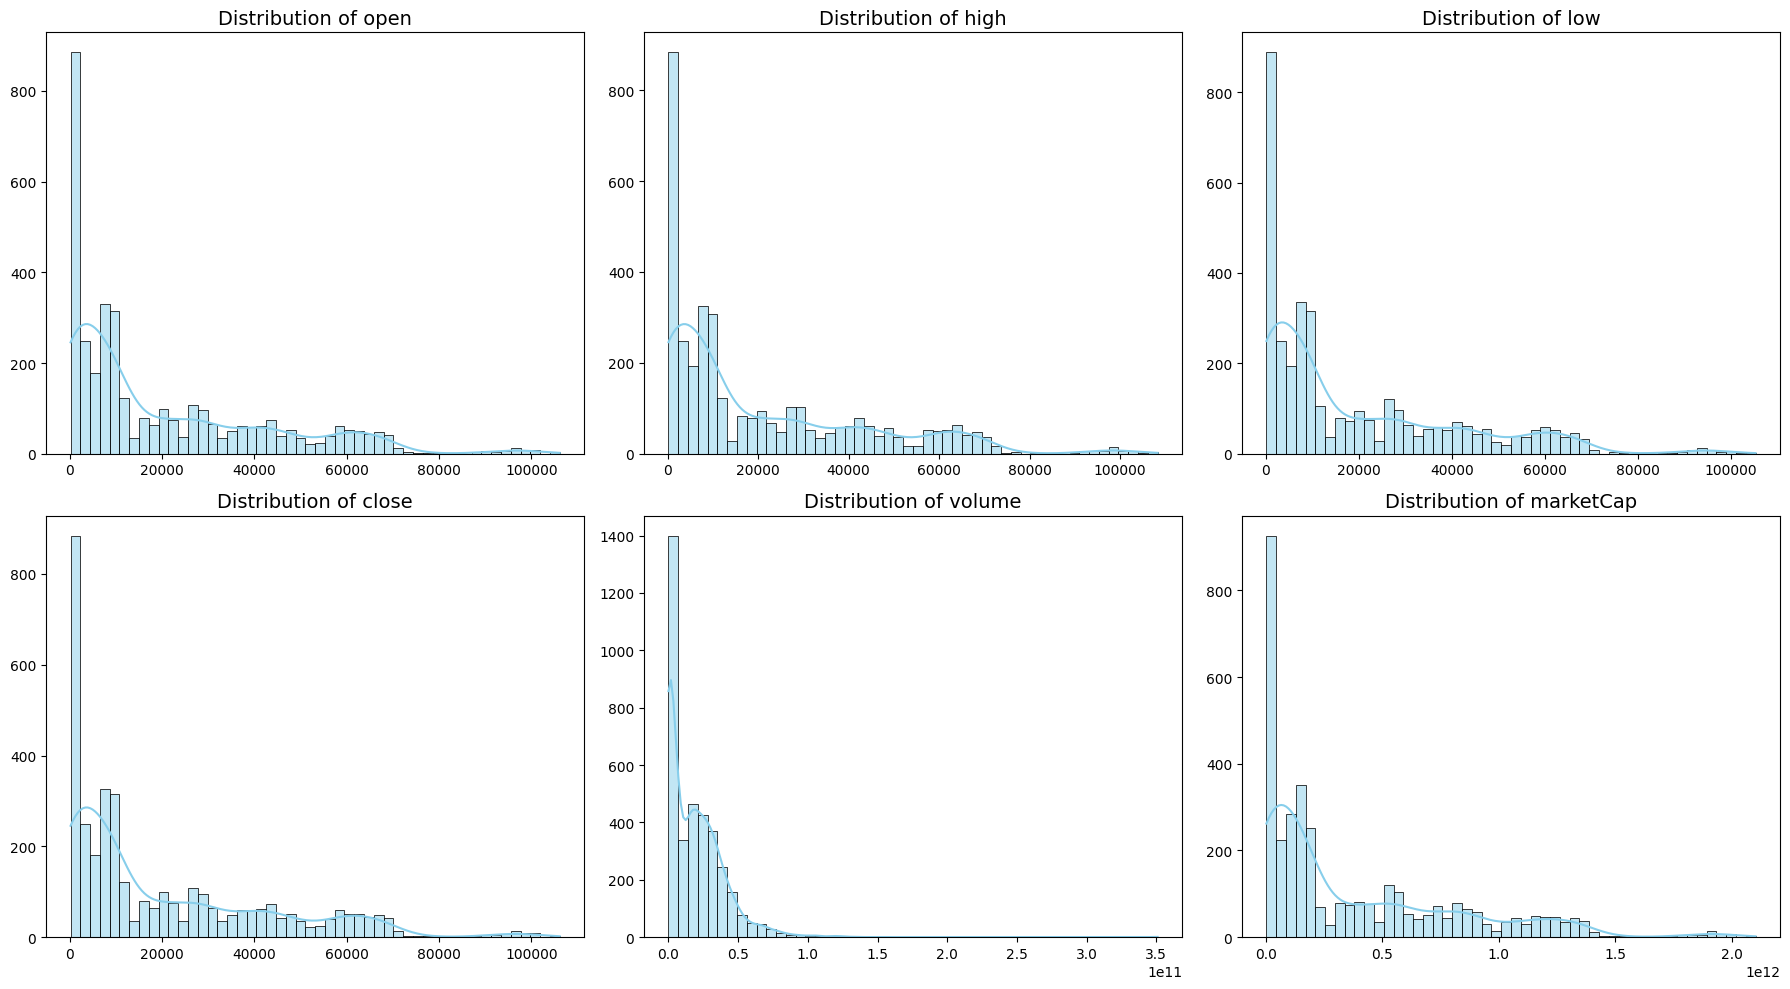

In [40]:
cols = ['open', 'high', 'low', 'close', 'volume', 'marketCap']

# Create a 2x3 grid for plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))  # 2 rows, 3 columns
axes = axes.flatten()

# Loop through each column and plot
for i, col in enumerate(cols):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color='skyblue', bins=50)
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

All the features appear right-skewed, which makes sense

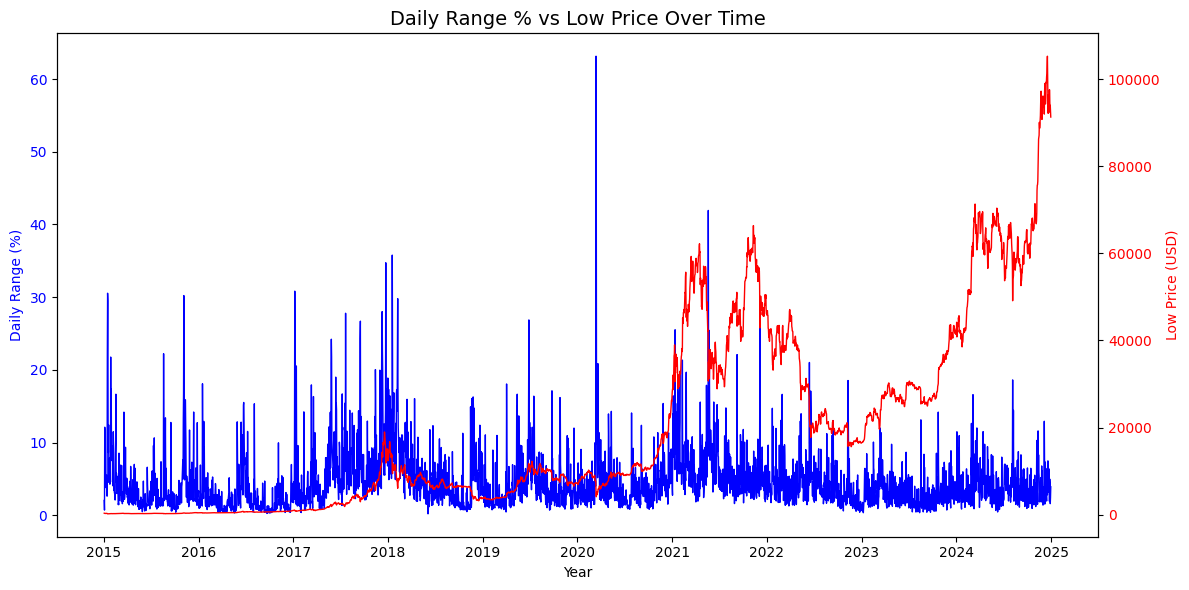

In [41]:
df_plot = df_clean.copy()
df_plot['time'] = df_plot[time]

# Compute daily percent change (high - low) / low
df_plot['daily_range_pct'] = (df_plot['high'] - df_plot['low']) / df_plot['low'] * 100

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot daily range percentage (blue line, left axis)
ax1.plot(df_plot['time'], df_plot['daily_range_pct'], color='blue', linewidth=1, label='Daily Range %')
ax1.set_xlabel("Year")
ax1.set_ylabel("Daily Range (%)", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Format x-axis to show only year labels
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(plt.matplotlib.dates.YearLocator())

# Create second y-axis for Low price
ax2 = ax1.twinx()
ax2.plot(df_plot['time'], df_plot['low'], color='red', linewidth=1, label='Low Price')
ax2.set_ylabel("Low Price (USD)", color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Daily Range % vs Low Price Over Time", fontsize=14)
fig.tight_layout()
plt.show()

In [42]:
# <Student to fill this section>
feature_1_insights = """
Plotting daily max percent change (high-low) and daily low price on the time series to see how the price have fluctuated over the years. This provides if there's a significant change over in a day, we may seem a sharp rise/drop in the days that follow. Almost always, more than 20% change has dictated the market. Although the distribution is volatile, it can still be used.
"""

In [43]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest `Price - Open and Close`

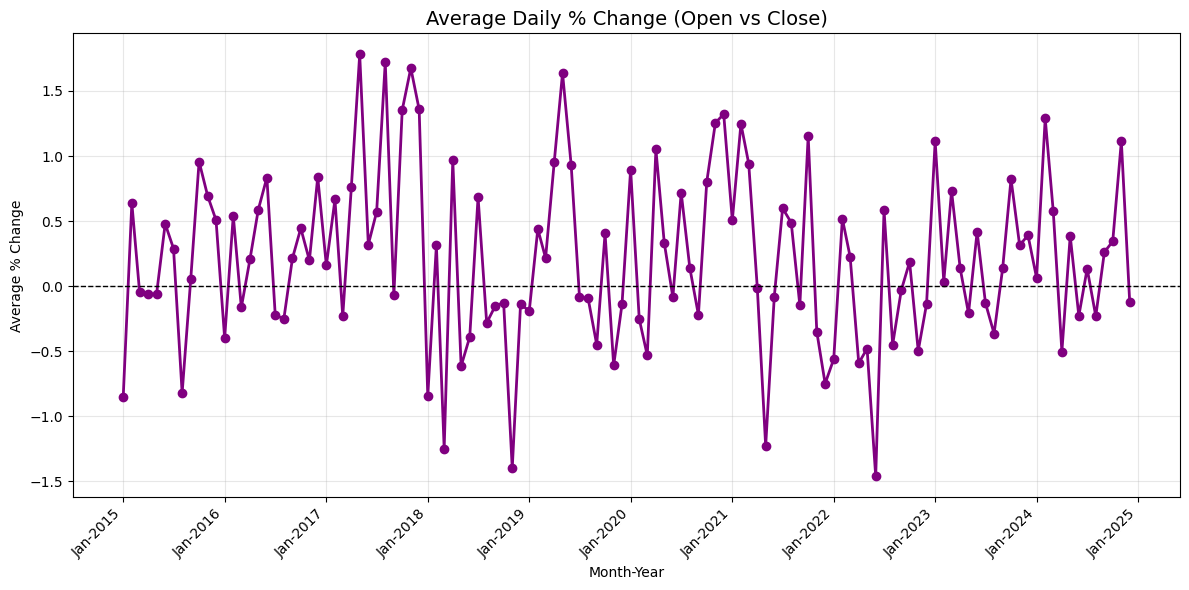

In [44]:
df_plot = df_clean.copy()
df_plot['time'] = df_plot[time]

# Compute daily percentage change between open and close
df_plot['open_close_pct'] = ((df_plot['close'] - df_plot['open']) / df_plot['open']) * 100

# Group by month and year to get average monthly performance
df_monthly = (
    df_plot.groupby(df_plot['time'].dt.to_period('M'))['open_close_pct']
    .mean()
    .reset_index()
)

# Convert period to timestamp for plotting
df_monthly['time'] = df_monthly['time'].dt.to_timestamp()

plt.figure(figsize=(12, 6))
plt.plot(df_monthly['time'], df_monthly['open_close_pct'], marker='o', color='purple', linewidth=2)
plt.axhline(0, color='black', linestyle='--', linewidth=1)  # baseline at 0

plt.title("Average Daily % Change (Open vs Close)", fontsize=14)
plt.xlabel("Month-Year")
plt.ylabel("Average % Change")
plt.grid(True, alpha=0.3)

# Format x-axis to show Month-Year labels clearly
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b-%Y'))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


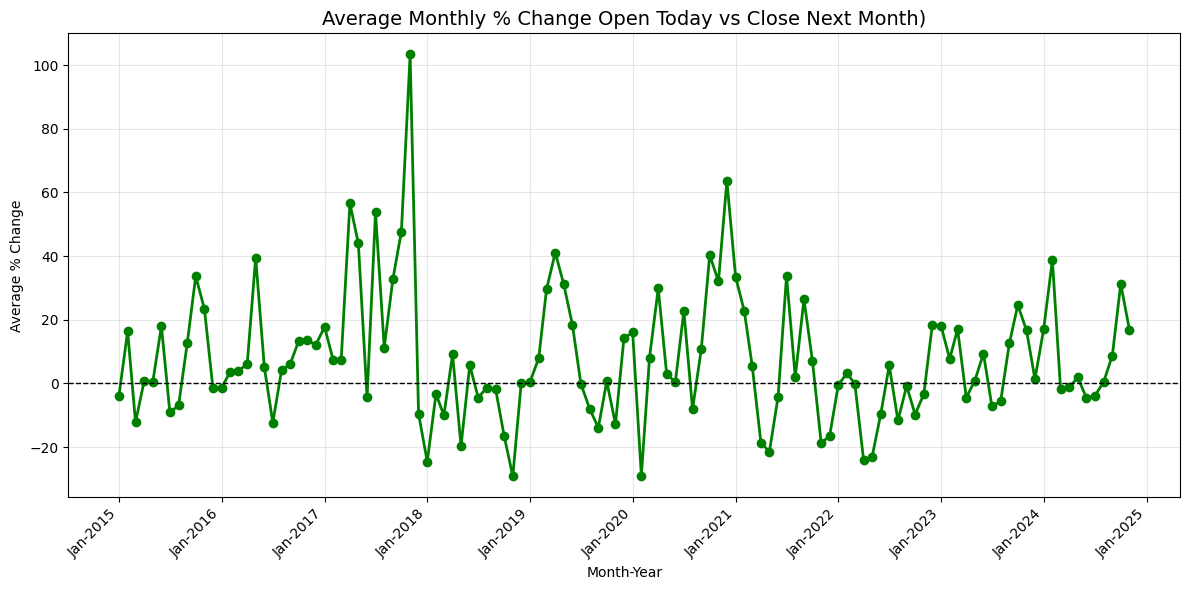

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

df_plot = df_clean.copy()
df_plot['time'] = df_plot[time]

df_plot['next_month_close'] = df_plot['close'].shift(-30)

# Compute percentage change from today's open to next month's close
df_plot['open_to_next_month_pct'] = ((df_plot['next_month_close'] - df_plot['open']) / df_plot['open']) * 100

# Drop rows where next_month_close is NaN (end of data)
df_plot = df_plot.dropna(subset=['open_to_next_month_pct'])

# Group by month-year of today's date for plotting
df_monthly = (
    df_plot.groupby(df_plot['time'].dt.to_period('M'))['open_to_next_month_pct']
    .mean()
    .reset_index()
)

# Convert period to timestamp for plotting
df_monthly['time'] = df_monthly['time'].dt.to_timestamp()

plt.figure(figsize=(12, 6))
plt.plot(df_monthly['time'], df_monthly['open_to_next_month_pct'], marker='o', color='green', linewidth=2)
plt.axhline(0, color='black', linestyle='--', linewidth=1)  # baseline at 0

plt.title("Average Monthly % Change Open Today vs Close Next Month)", fontsize=14)
plt.xlabel("Month-Year")
plt.ylabel("Average % Change")
plt.grid(True, alpha=0.3)

# Format x-axis to show Month-Year labels clearly
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b-%Y'))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


In [46]:
# <Student to fill this section>
feature_2_insights = """
We plotted the daily average change (open-close) and monthly change to see how the coin has moved in the past to come to the present price range. This also helps in understanding the correlation between open and close price. Consistent negative average move states a trend reversal in the foreseeable future, and vice versa.
"""

In [47]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.7 Explore Feature of Interest `Liquidity`


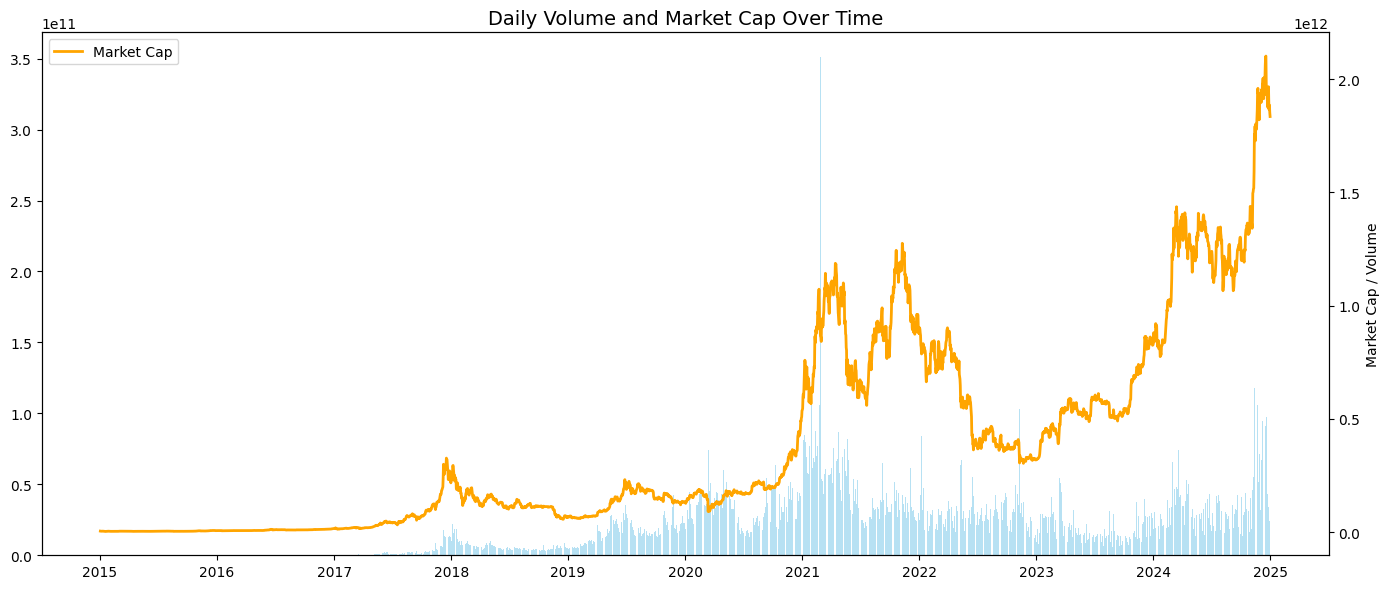

In [48]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_plot = df_clean.copy()

plt.figure(figsize=(14,6))

# Plot volume as bar
plt.bar(df_plot[time], df_plot['volume'], color='skyblue', label='Volume', alpha=0.6)

# Plot marketCap as line on secondary y-axis
plt.twinx()
plt.plot(df_plot[time], df_plot['marketCap'], color='orange', label='Market Cap', linewidth=2)

# Formatting x-axis to show only year labels
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45, ha='right')

plt.title("Daily Volume and Market Cap Over Time", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Market Cap / Volume")
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [49]:
# <Student to fill this section>
feature_n_insights = """
Volume disctates the target in a negative correlated sense, more the volume (volatility) higher the chance of trend reversal. Market cap as expected moves with the price ranges.
"""

In [50]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)

---
## D. Feature Selection


### D.1 Pearson's Correlation Test


Correlation with target_next_high:

                  target_next_high
target_next_high          1.000000
close                     0.999566
high                      0.999327
marketCap                 0.998933
open                      0.998741
volume                    0.666213


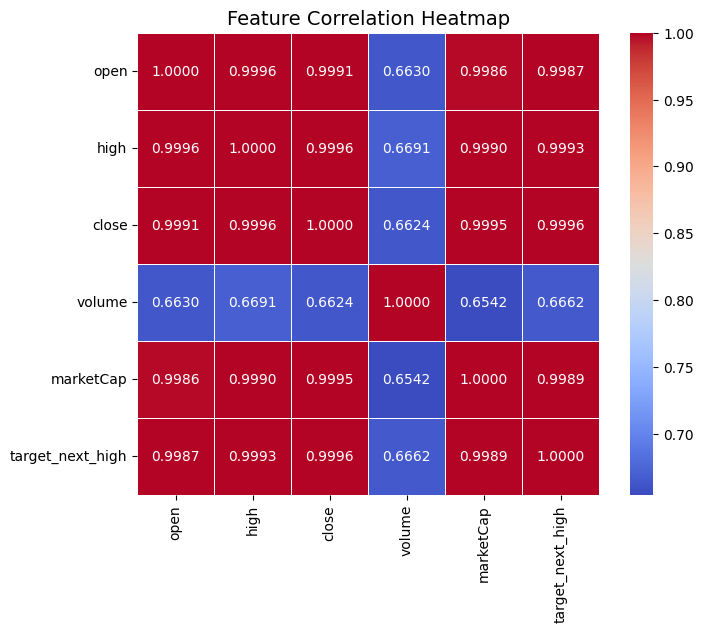

In [51]:
cols = ['open', 'high', 'close', 'volume', 'marketCap', 'target_next_high']

# Compute correlation matrix
corr_matrix = df_clean[cols].corr(method='pearson')

# Display only correlations with target_next_high
target_corr = corr_matrix[['target_next_high']].sort_values(by='target_next_high', ascending=False)
print("Correlation with target_next_high:\n")
print(target_corr)

# Plot full correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".4f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.show()


In [52]:
# <Student to fill this section>
feature_selection_1_insights = """
> Target variable is driven almost entirely by price features
> Volume may be used as an auxiliary feature but not as a dominant predictor
"""

In [53]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### D.2 Lasso Feature Ranking


In [54]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import pandas as pd

cols = ['open', 'high', 'close', 'volume', 'marketCap', 'target_next_high']
X = df_clean[cols].drop(columns=['target_next_high'])
y = df_clean['target_next_high']

# Standardize features for regularization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit Lasso regression (alpha controls regularization strength)
lasso = Lasso(alpha=0.001, random_state=42)
lasso.fit(X_scaled, y)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso.coef_,
    'Importance': abs(lasso.coef_)
}).sort_values(by='Importance', ascending=False)

importance = importance.round(4)

print("Feature Ranking using L1 Regularization (Lasso):\n")
print(importance)

Feature Ranking using L1 Regularization (Lasso):

     Feature  Coefficient  Importance
2      close   11163.6843  11163.6843
1       high   10889.8025  10889.8025
0       open    1478.8947   1478.8947
4  marketCap    -892.9259    892.9259
3     volume      15.6356     15.6356


In [55]:
# <Student to fill this section>
feature_selection_2_insights = """
> Lasso acts as both a predictor and feature selector.
> α = 0.001 allows subtle regularization to reduce noise while keeping meaningful relationships.
> The closing price is the strongest predictor of next day’s high, meaning the model relies most on how the market closed previously.
> The current day’s high also strongly predicts the next high (momentum or continuation effect).
> As market cap increases, next day’s high tends to increase at a slower rate (inverse or stabilizing effect).
"""

In [56]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

### D.3 Final Selection of Features

In [57]:
df_clean = df_clean.set_index('timestamp').sort_index()

In [58]:
df_clean.head()

,timeOpen,timeHigh,timeLow,timeClose,open,high,low,close,volume,marketCap,target_next_high
timestamp,,,,,,,,,,,
2015-01-01 23:59:59.999000+00:00,2015-01-01 00:00:00+00:00,2015-01-01T00:04:00.000Z,2015-01-01T23:44:00.000Z,2015-01-01 23:59:59.999000+00:00,320.434998,320.434998,314.002991,314.248993,8036550.0,4.297536e+09,315.838989
2015-01-02 23:59:59.999000+00:00,2015-01-02 00:00:00+00:00,2015-01-02T20:19:01.000Z,2015-01-02T01:04:01.000Z,2015-01-02 23:59:59.999000+00:00,314.079010,315.838989,313.565002,315.032013,7860650.0,4.309551e+09,315.149994
2015-01-03 23:59:59.999000+00:00,2015-01-03 00:00:00+00:00,2015-01-03T00:24:01.000Z,2015-01-03T23:59:00.000Z,2015-01-03 23:59:59.999000+00:00,314.846008,315.149994,281.082001,281.082001,33054400.0,3.846270e+09,287.230011
2015-01-04 23:59:59.999000+00:00,2015-01-04 00:00:00+00:00,2015-01-04T10:14:01.000Z,2015-01-04T15:29:01.000Z,2015-01-04 23:59:59.999000+00:00,281.145996,287.230011,257.612000,264.195007,55629100.0,3.616321e+09,278.341003
2015-01-05 23:59:59.999000+00:00,2015-01-05 00:00:00+00:00,2015-01-05T08:54:00.000Z,2015-01-05T00:04:01.000Z,2015-01-05 23:59:59.999000+00:00,265.084015,278.341003,265.084015,274.473999,43962800.0,3.758098e+09,287.553009


In [59]:
features_list = [
    'open',
    'high',
    'low',
    'close',
    'volume',
    'marketCap',
    'target_next_high']

In [60]:
# <Student to fill this section>
feature_selection_explanations = """
Based on the feature selection techniques, we arrived at these columns. Since there are not many features to work around, we decide to keep the 'volume' as well which can feature engineered and can be highly useful. Using timestamp as index, we will further work using time-frame. Dropped timstamps for OHLC since they are only helpful in intra-day trading (same day entry-exit), hence not really helpful with predicting next day's target.
"""

In [61]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Log Transformations

In [81]:
df_eng = df_clean[features_list].copy()

In [82]:
cols_to_transform = ['open', 'high', 'low', 'close', 'volume', 'marketCap']

# Log-transform features
for col in cols_to_transform:
    df_eng[col] = np.log1p(df_eng[col])

# Log-transform target
df_eng['target_next_high'] = np.log1p(df_eng['target_next_high'])

# inverse-transform predictions after model output
# y_pred_original = np.expm1(y_pred_log)


In [83]:
df_eng.head()

,open,high,low,close,volume,marketCap,target_next_high
timestamp,,,,,,,
2015-01-01 23:59:59.999000+00:00,5.772795,5.772795,5.752582,5.753363,15.899511,22.181308,5.758394
2015-01-02 23:59:59.999000+00:00,5.752823,5.758394,5.751191,5.755844,15.877380,22.184100,5.756217
2015-01-03 23:59:59.999000+00:00,5.755255,5.756217,5.642198,5.642198,17.313665,22.070370,5.663759
2015-01-04 23:59:59.999000+00:00,5.642425,5.663759,5.555329,5.580465,17.834217,22.008723,5.632433
2015-01-05 23:59:59.999000+00:00,5.583812,5.632433,5.583812,5.618493,17.598854,22.047179,5.664879


In [64]:
# <Student to fill this section>
data_cleaning_1_explanations = """
Since we are going to be training our dataset using AdaBoost, a tree-based model, we don't have to worry about standardization. Although, it requires log transformations for skewed data to stabilize variance. We have applied log transformation on all the required features and to the target as well. In the end, to produce final results, we are going to inverse-transform to display the actual results.
"""

In [65]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

---
## F. Feature Engineering
> Following features are a direct result of already existing financial indicators in the stock market

### F.1 Trend and Momentum Indicator


We are computing Exponential Moving Average and Relative Strength Indicator in this section.

In [84]:
price_col = 'close'
volume_col = 'volume'

In [85]:
# Exponential Moving Average (EMA)
df_eng['ma_exp'] = df_eng[price_col].ewm(span=7, adjust=False).mean()

# Relative Strength Index (RSI)
delta = df_eng[price_col].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
# Calculate average gain and loss using exponential moving average
avg_gain = gain.ewm(span=7, adjust=False).mean()
avg_loss = loss.ewm(span=7, adjust=False).mean()
# Calculate RSI
rs = avg_gain / avg_loss
df_eng['rel_strength'] = 100 - (100 / (1 + rs))

In [86]:
# <Student to fill this section>
feature_engineering_1_explanations = """
> Average of closing prices over a fixed period. Weighted average gives more importance to recent prices. It captures short-term trends while smoothing out noise
> RSI measures overbought/oversold conditions - hence indicating momntum in the market. It indicates overbought or oversold conditions, helping identify potential trend reversals.
"""

In [87]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 Volatility - Standard Deviation of Price

In [88]:
# Rolling Standard Deviation of price
df_eng['sd_price'] = df_eng[price_col].rolling(window=7).std()

In [89]:
# <Student to fill this section>
feature_engineering_2_explanations = """
Measures dispersion of closing prices over a period. Explains volatile situations and can be used to handle outlier conditions. It helps identify periods of high or low volatility, which can indicate risk or potential price breakout
"""

In [90]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### F.3 Volume-based Indicator - Volume Weighted Average Price

In [91]:
# 3. Volume Weighted Average Price (VWAP) ---
# VWAP = cumulative sum of (price * volume) / cumulative volume
df_eng['vol_wap'] = (df_eng[price_col] * df_eng[volume_col]).cumsum() / df_eng[volume_col].cumsum()

In [92]:
# <Student to fill this section>
feature_engineering_n_explanations = """
To use volume define the target variable behaviour, we are integrating it with price. It's a volume based indicator. It also shows the average price buyers and sellers are paying, giving insight into true market price levels.
"""

In [93]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n_explanations', value=feature_engineering_n_explanations)

---
## G. Split datasets

In [94]:
df_final = df_eng.copy()
df_final = df_final.dropna().reset_index(drop=True)

In [95]:
df_final.head()

,open,high,low,close,volume,marketCap,target_next_high,ma_exp,rel_strength,sd_price,vol_wap
0,5.659750,5.702962,5.649252,5.688117,17.029044,22.117592,5.687433,5.673725,56.700683,0.066050,5.668693
1,5.687433,5.687433,5.646065,5.650202,16.810367,22.079814,5.677144,5.667844,41.906105,0.055305,5.666396
2,5.646799,5.677144,5.640250,5.674724,16.745028,22.104655,5.666866,5.669564,52.576764,0.036226,5.667313
3,5.664012,5.666866,5.616647,5.619661,16.541027,22.049687,5.637066,5.657088,33.922139,0.037486,5.662638
4,5.618980,5.637066,5.583643,5.585974,16.716976,22.016158,5.610215,5.639310,26.307980,0.036016,5.655723


In [97]:
n = len(df_final)

# Compute split indices
train_end = int(0.7 * n)
val_end = int(0.8 * n)

# Train, validation, test split (chronological)
df_train = df_final.iloc[:train_end].copy()
df_val = df_final.iloc[train_end:val_end].copy()
df_test = df_final.iloc[val_end:].copy()

print("Train shape:", df_train.shape)
print("Validation shape:", df_val.shape)
print("Test shape:", df_test.shape)

Train shape: (2552, 11)
Validation shape: (364, 11)
Test shape: (730, 11)


In [98]:
target_name

'target_next_high'

In [99]:
df_val.head()

,open,high,low,close,volume,marketCap,target_next_high,ma_exp,rel_strength,sd_price,vol_wap
2552,10.772308,10.776503,10.754876,10.765242,24.053739,27.520858,10.768732,10.771608,44.476369,0.029739,8.431166
2553,10.765207,10.768732,10.732846,10.746328,24.221942,27.501990,10.766537,10.765288,33.485469,0.012450,8.432185
2554,10.746344,10.766537,10.731023,10.734189,24.472645,27.489899,10.756413,10.757514,27.640652,0.013834,8.433207
2555,10.734228,10.756413,10.664275,10.682124,24.330151,27.437883,10.686240,10.738666,13.832564,0.030285,8.434200
2556,10.682044,10.686240,10.660701,10.672714,24.131374,27.428520,10.672544,10.722178,12.346264,0.038871,8.435180


In [100]:
# Train set
X_train = df_train.drop(columns=[target_name])
y_train = df_train[target_name]

# Validation set
X_val = df_val.drop(columns=[target_name])
y_val = df_val[target_name]

# Test set
X_test = df_test.drop(columns=[target_name])
y_test = df_test[target_name]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (2552, 10) y_train: (2552,)
X_val: (364, 10) y_val: (364,)
X_test: (730, 10) y_test: (730,)


In [101]:
# <Student to fill this section>
data_splitting_explanations = """
Dataset index is already timstamped. Given the problem and objective, data split cannot be random and time-series has to be given importance. Hence the selection of split. Next, since the rows of data is too less, we are only using 10% of the data for validation.
"""

In [338]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

---
## H. Save Datasets

> Do not change this code

In [188]:
class AT:
    def __init__(self, folder_path):
        self.folder_path = Path(folder_path)


at = AT("./data/processed")
at.folder_path.mkdir(parents=True, exist_ok=True)

at.folder_path

WindowsPath('data/processed')

In [102]:
# Do not modify this code
# Save training set
try:
  X_train.to_csv(at.folder_path / 'X_train.csv', index=False)
  y_train.to_csv(at.folder_path / 'y_train.csv', index=False)

  X_val.to_csv(at.folder_path / 'X_val.csv', index=False)
  y_val.to_csv(at.folder_path / 'y_val.csv', index=False)

  X_test.to_csv(at.folder_path / 'X_test.csv', index=False)
  y_test.to_csv(at.folder_path / 'y_test.csv', index=False)
except Exception as e:
  print(e)

---
## I. Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [135]:
from sklearn.metrics import mean_squared_error, r2_score

# y_true = actual values
# y_pred = model predictions

def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    # print("Model Performance Metrics:")
    # print(f"Mean Squared Error (MSE): {mse:.4f}")
    # print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    # print(f"R² Score: {r2:.4f}")
    
    return {"MSE": mse, "RMSE": rmse, "R2": r2}

INVERT_TARGET = False
def target_inverse(arr):
    if INVERT_TARGET:
        return np.expm1(arr)
    return arr

In [119]:
# <Student to fill this section>
performance_metrics_explanations = """
> MSE (Mean Squared Error): Penalizes large errors more heavily.
> RMSE (Root Mean Squared Error): Square root of MSE, interpretable in the same scale as the target.
> R2 (Coefficient of Determination): Explains how much variance in target is explained by the model (1.0 = perfect).
> Perfect indicators to explain the error and improve upon that. 
"""

In [120]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm 1

> Provide some explanations on why you believe this algorithm is a good fit


In [127]:
# <Student to fill this section>
algorithm_selection_explanations = """
AdaBoostRegressor with small decision trees (stumps or small depth) captures non-linear relationships while reducing overfitting risk.
"""

In [128]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [129]:
# Candidate hyperparameter grid (small set you can expand)
param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.5],
    "max_depth": [1, 2, 3]
}

# TimeSeries CV setup
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)  # rolling CV

X_for_tuning = X_train.copy()
y_for_tuning = y_train.copy()

best_score = float("inf")
best_params = None
results = []

In [130]:
import time

In [131]:
# Manual grid search with time-series CV (deterministic)
start_search = time.time()

for n_est in param_grid["n_estimators"]:
    for lr in param_grid["learning_rate"]:
        for depth in param_grid["max_depth"]:
            val_scores = []
            # For each fold in time-split, train on earlier portion and validate on later portion
            for train_idx, val_idx in tscv.split(X_for_tuning):
                X_tr, X_va = X_for_tuning.iloc[train_idx], X_for_tuning.iloc[val_idx]
                y_tr, y_va = y_for_tuning.iloc[train_idx], y_for_tuning.iloc[val_idx]

                base = DecisionTreeRegressor(max_depth=depth, random_state=42)
                model = AdaBoostRegressor(estimator=base, n_estimators=n_est,
                                          learning_rate=lr, random_state=42)
                model.fit(X_tr, y_tr)
                y_va_pred = model.predict(X_va)

                y_va_true_orig = target_inverse(y_va.values)
                y_va_pred_orig = target_inverse(y_va_pred)

                rmse = np.sqrt(mean_squared_error(y_va_true_orig, y_va_pred_orig))
                val_scores.append(rmse)

            mean_val_rmse = float(np.mean(val_scores))
            results.append({
                "n_estimators": n_est,
                "learning_rate": lr,
                "max_depth": depth,
                "val_rmse": mean_val_rmse
            })

            # update best
            if mean_val_rmse < best_score:
                best_score = mean_val_rmse
                best_params = {"n_estimators": n_est, "learning_rate": lr, "max_depth": depth}

end_search = time.time()

In [132]:
# Show best result summary
print("Time-series CV tuning finished in {:.1f}s".format(end_search - start_search))
print("Best params (by CV RMSE):", best_params)
print("Best CV RMSE:", round(best_score, 4))

Time-series CV tuning finished in 50.8s
Best params (by CV RMSE): {'n_estimators': 200, 'learning_rate': 0.5, 'max_depth': 3}
Best CV RMSE: 0.6424


In [111]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
Use TimeSeriesSplit to avoid look-ahead bias. For each hyperparam combination compute average validation RMSE across splits. Pick the best.
"""

In [112]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [133]:
# Instantiate base estimator and AdaBoost with best params
final_base = DecisionTreeRegressor(max_depth=best_params["max_depth"], random_state=42)
final_model = AdaBoostRegressor(estimator=final_base,
                                n_estimators=best_params["n_estimators"],
                                learning_rate=best_params["learning_rate"],
                                random_state=42)

# FIT (only .fit as required)
final_model.fit(X_train, y_train)

AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=3, random_state=42),
                  learning_rate=0.5, n_estimators=200, random_state=42)

### J.4 Model Technical Performance

> Provide some explanations on model performance


In [136]:
# Predictions
y_train_pred = final_model.predict(X_train)
y_val_pred = final_model.predict(X_val)
y_test_pred = final_model.predict(X_test)

# Inverse transform 
y_train_true = target_inverse(y_train.values)
y_val_true = target_inverse(y_val.values)
y_test_true = target_inverse(y_test.values)

y_train_pred_orig = target_inverse(y_train_pred)
y_val_pred_orig = target_inverse(y_val_pred)
y_test_pred_orig = target_inverse(y_test_pred)

# Compute metrics
metrics_train = regression_metrics(y_train_true, y_train_pred_orig)
metrics_val = regression_metrics(y_val_true, y_val_pred_orig)
metrics_test = regression_metrics(y_test_true, y_test_pred_orig)

# Print results nicely
print("\nModel performance (original-target scale):")
print("TRAIN -> MSE: {MSE:.4f}, RMSE: {RMSE:.4f}, R2: {R2:.4f}".format(**metrics_train))
print("VALID -> MSE: {MSE:.4f}, RMSE: {RMSE:.4f}, R2: {R2:.4f}".format(**metrics_val))
print("TEST  -> MSE: {MSE:.4f}, RMSE: {RMSE:.4f}, R2: {R2:.4f}".format(**metrics_test))


Model performance (original-target scale):
TRAIN -> MSE: 0.0109, RMSE: 0.1045, R2: 0.9962
VALID -> MSE: 0.0549, RMSE: 0.2343, R2: 0.5677
TEST  -> MSE: 0.1030, RMSE: 0.3209, R2: 0.5176


In [ ]:
# <Student to fill this section>
model_performance_explanations = """
Provide some explanations on model performance
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [ ]:
# <Student to fill this section>

In [ ]:
# <Student to fill this section>
business_impacts_explanations = """
Interpret the results of the experiments related to the business objective set earlier. Estimate the impacts of the incorrect results for the business (some results may have more impact compared to others)
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

### J.6 Import Algorithm 2

> Provide some explanations on why you believe this algorithm is a good fit

In [ ]:
from xgboost import XGBRegressor

> Insights


We use XGBRegressor because it’s highly effective for tabular and time-series-like structured data, handles non-linearity well, and provides strong performance with minimal feature scaling.

### J.7 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit

In [144]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.001, 0.01, 0.1],
    'max_depth': [5, 15, 25],
    'subsample': [0.8, 1.0],
}

best_params = None
best_rmse = np.inf

for n in param_grid['n_estimators']:
    for lr in param_grid['learning_rate']:
        for md in param_grid['max_depth']:
            for ss in param_grid['subsample']:
                model = XGBRegressor(
                    n_estimators=n,
                    learning_rate=lr,
                    max_depth=md,
                    subsample=ss,
                    objective='reg:squarederror',
                    random_state=42
                )
                model.fit(X_train, y_train)
                
                y_val_pred = model.predict(X_val)
                rmse = np.sqrt(np.mean((np.expm1(y_val_pred) - np.expm1(y_val)) ** 2))  # anti-log for RMSE
                
                if rmse < best_rmse:
                    best_rmse = rmse
                    best_params = {
                        'n_estimators': n,
                        'learning_rate': lr,
                        'max_depth': md,
                        'subsample': ss
                    }

print("Best hyperparameters:", best_params)
print("Best validation RMSE:", best_rmse)

Best hyperparameters: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 15, 'subsample': 0.8}
Best validation RMSE: 1051.360631418756


> Insights


We’re not using GridSearchCV since it randomly shuffles by default — which breaks time ordering. Instead, this manual loop preserves time structure and evaluates based on validation RMSE after applying np.expm1() to reverse the log transform.

### J.8 Fit Model

In [145]:
# Combine train and val for final training
X_full_train = pd.concat([X_train, X_val])
y_full_train = pd.concat([y_train, y_val])

final_model = XGBRegressor(
    **best_params,
    objective='reg:squarederror',
    random_state=42
)

final_model.fit(X_full_train, y_full_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=15,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

> Insights

After tuning, we retrain on all available data (train + validation) to give the model the most context before testing.

### J.9 Model Technical Performance

> Provide some explanations on model performance


In [150]:
# Predict and invert log transformation
y_train_pred = np.expm1(final_model.predict(X_train))
y_val_pred = np.expm1(final_model.predict(X_val))
y_test_pred = np.expm1(final_model.predict(X_test))

# Invert log transform on y as well
y_train_true = np.expm1(y_train)
y_val_true = np.expm1(y_val)
y_test_true = np.expm1(y_test)

print("Train performance:")
print(regression_metrics(y_train_true, y_train_pred))

print("\nValidation performance:")
print(regression_metrics(y_val_true, y_val_pred))

print("\nTest performance:")
print(regression_metrics(y_test_true, y_test_pred))

Train performance:
{'MSE': np.float64(2344.465248469316), 'RMSE': np.float64(48.41967831852372), 'R2': 0.9999912360194056}

Validation performance:
{'MSE': np.float64(4384.244002880812), 'RMSE': np.float64(66.21362399748871), 'R2': 0.9999591382535286}

Test performance:
{'MSE': np.float64(82573923.94548064), 'RMSE': np.float64(9087.019530378519), 'R2': 0.8310678532117552}


> Insights

- Train & Val: Model fits almost perfectly.
- Test: High error = overfitting + concept drift.
- R² = 0.83 still indicates the model explains most of the variation — not random.

### J.10 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view

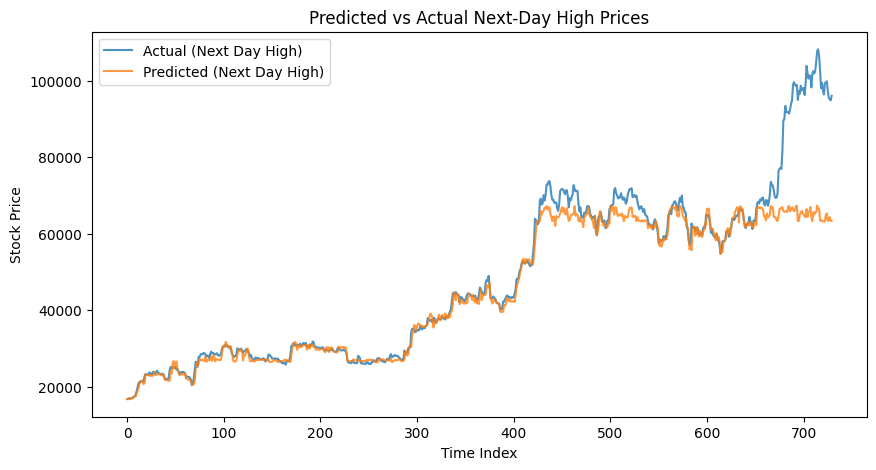

In [ ]:
x_axis = np.arange(len(y_test_true))

plt.figure(figsize=(10,5))
plt.plot(x_axis, y_test_true, label='Actual (Next Day High)', alpha=0.8)
plt.plot(x_axis, y_test_pred, label='Predicted (Next Day High)', alpha=0.8)
plt.title('Predicted vs Actual Next-Day High Prices')
plt.xlabel('Time Index')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

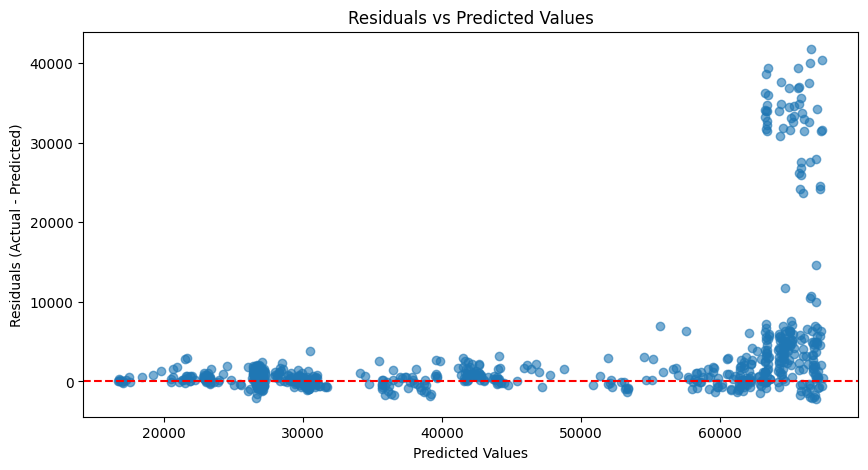

In [153]:
residuals = y_test_true - y_test_pred
plt.figure(figsize=(10,5))
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

> Insights

- Prediction Drift: The model significantly underestimates the actual price rise after Time Index ~650, showing poor generalization to high-volatility periods.
- Large Residuals: The Residuals Plot shows error size is highly dependent on the prediction value (heteroscedasticity), with the largest positive errors occurring for the highest predicted prices (>$60,000).
- Limitation: The model likely lacks features capturing sudden, external market shocks (e.g., news events, policy changes) that drove the final sharp price increase.

## K. Save Best Model

Saving XGBoost Model in `./models/`

In [192]:
import pickle
from pathlib import Path

model_loc = Path("./models")
model_loc.mkdir(parents=True, exist_ok=True)  # create folder if it doesn't exist

with open(model_loc / "best_model.pkl", "wb") as f:
    pickle.dump(final_model, f)